# Ćwiczenia 3: Manipulowanie danymi tabelarycznymi i łączenie tabel

## Zadanie 0.

Pobierz archiwum ZIP z danymi. Rozpakuj archiwum do katalogu o takiej samej nazwie jak archiwum. Umieść katalog z danymi w odpowiednim katalogu. Upewnij się, że jest on widoczny w środowisku programistycznym.

## Zadanie 1.

Zaimportuj moduł `pandas` z odpowiednim aliasem. Wczytaj następujące tabele:
* `data/synthea_sample_data_csv_latest/patients.csv`,
* `data/synthea_sample_data_csv_latest/encounters.csv`,
* `data/synthea_sample_data_csv_latest/conditions.csv`,
* `data/synthea_sample_data_csv_latest/medications.csv`.

Wyświetl rozmiar wczytanych tabel w następującym formacie: *{nazwa tabeli}: {liczba wierszy} wierszy, {liczba kolumn} kolumn.*

In [16]:
import pandas as pd
pain = pd.read_csv("DATA/synthea_sample_data_csv_latest/patients.csv") #pacjenci
vis = pd.read_csv("DATA/synthea_sample_data_csv_latest/encounters.csv") #wizyty
diag = pd.read_csv("DATA/synthea_sample_data_csv_latest/conditions.csv") #diagnozy
med = pd.read_csv("DATA/synthea_sample_data_csv_latest/medications.csv") #leki

print(f"nazwa tabeli: Pacjenci — wiersze: {pain.shape[0]}, kolumny: {pain.shape[1]}")
print(f"nazwa tabeli: Wizyty — wiersze: {vis.shape[0]}, kolumny: {vis.shape[1]}")
print(f"nazwa tabeli: Diagnozy — wiersze: {diag.shape[0]}, kolumny: {diag.shape[1]}") 
print(f"nazwa tabeli: Leki — wiersze: {med.shape[0]}, kolumny: {med.shape[1]}")

nazwa tabeli: Pacjenci — wiersze: 115, kolumny: 28
nazwa tabeli: Wizyty — wiersze: 7095, kolumny: 15
nazwa tabeli: Diagnozy — wiersze: 4516, kolumny: 7
nazwa tabeli: Leki — wiersze: 5807, kolumny: 13


## Zadanie 2.

Dokonaj przeglądu wczytanych tabel w celu zbadania struktury relacyjnej. Zidentyfikuj kolumny kluczy, dzięki którym można łączyć tabele. Zbadaj jakie typy wizyt występują w zbiorze i przedstaw rozkład ilości wizyt dla każdego typu.

In [22]:
vis.ENCOUNTERCLASS.value_counts()
#dla nazw kolumn bez spacji i znaków specjalnych: można je używać jako obiekty
#schemat struktury relacyjnej zdjęcie!

ENCOUNTERCLASS
ambulatory    3876
wellness      1316
outpatient     996
urgentcare     426
emergency      334
inpatient       81
virtual         35
snf             16
hospice         15
Name: count, dtype: int64

## Zadanie 3.

Przeanalizuj wizyty pod kątem demografii pacjentów. W tym celu wykonaj następujące kroki:
* złącz tabele `pacjenci` i `wizyty` z użyciem funkcji `pd.merge()`, zadbaj o rozwiązanie konfliktu nazw kolumn,
* oblicz wiek pacjentów w momencie wizyty (przekonwertuj kolumny `pacjenci.BRITHDATE` i `wizyty.START` na odpowiedni typ),
* dokonaj kategoryzacji wieku pacjentów z użyciem funkcji `pd.cut()`,
* zaprezentuj rozkład liczby pacjentów w poszczególnych grupach wiekowych używając metody `.value_counts()`.

In [40]:
pv = pd.merge(pain, vis, left_on="Id", right_on="PATIENT", suffixes=["_pain", "_vis"])
#parametry merge
#1. jakie tabele chcemy złączyć
#2. lefton, jakie klucze z lewej/ pierwszej tabeli

In [41]:
pv.BIRTHDATE = pd.to_datetime(pv.BIRTHDATE)
pv.START = pd.to_datetime(pv.START)

In [49]:
pv.START #godzina wizyty ma określoną strefę czasową
#więc trzeba przekonwertować
pv["AGE"] = (pv.START.dt.tz_localize(None) - pv.BIRTHDATE).dt.days // 365
#strefa czasowa zniknęła, ALE wynikiem są dni

In [56]:
bins = [0, 18, 35, 50, 65, 150]
etk = ["0–17", "18–34", "35–49", "50–64", "65–150"]
pv["AGE_RANGE"] = pd.cut(pv.AGE, bins, labels=etk)

In [57]:
pv.AGE_RANGE.value_counts()

AGE_RANGE
65–150    1654
50–64     1481
35–49     1355
18–34     1346
0–17      1180
Name: count, dtype: int64

## Zadanie 4.

Sprawdź rozkład liczby wizyt według płci. Dokonaj analizy otrzymanego wyniku i sprawdź pochodzenie odkrytej rozbieżności.

In [71]:
pv.groupby("GENDER").size() / pain.GENDER.value_counts()

GENDER
F    62.018519
M    61.409836
dtype: float64

## Zadanie 5.

Zbadaj średni koszt wizyty w podziale na typ wizyty. Zbadaj sumę kosztów każdego typu wizyty. Wynik zaokrąglij do dwóch miejsc po przecinku. Zinterpretuj wyniki.

In [73]:
pv.groupby("ENCOUNTERCLASS").TOTAL_CLAIM_COST.mean().round(2)


ENCOUNTERCLASS
ambulatory     3574.11
emergency      3033.06
hospice        8564.21
inpatient      8008.70
outpatient     1303.67
snf           15805.69
urgentcare      850.13
virtual         185.72
wellness       1227.51
Name: TOTAL_CLAIM_COST, dtype: float64

## Zadanie 6.

Zbadaj średni koszt poszczególnych kategorii w podziale na płeć pacjenta. Wynik zaokrąglij do 2 miejsc po przecinku. Dokonaj interpretacji otrzymanego wyniku.

In [75]:
pv.groupby(["ENCOUNTERCLASS", "GENDER"]).TOTAL_CLAIM_COST.mean().round(2).unstack()

GENDER,F,M
ENCOUNTERCLASS,,
ambulatory,4981.56,2324.34
emergency,3019.94,3043.62
hospice,9012.04,8172.36
inpatient,5106.08,9716.12
outpatient,1564.00,892.25
snf,23845.44,12151.26
urgentcare,938.76,809.89
virtual,833.39,125.00
wellness,1293.11,1174.36


## Zadanie 7.

Przedstaw dane z powyższego zadania i przedstaw je na wykresie słupkowym porównując koszty między płciami.

<Axes: xlabel='ENCOUNTERCLASS'>

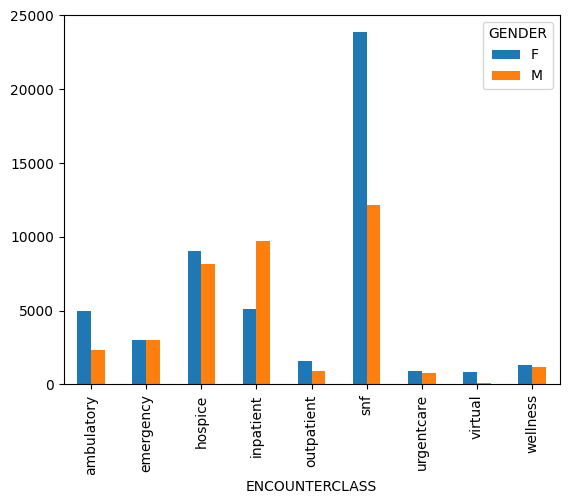

In [80]:
pv.groupby(["ENCOUNTERCLASS", "GENDER"]).TOTAL_CLAIM_COST.mean().round(2).unstack().plot(kind="bar")

## Zadanie 8.

Przeanalizuj najczęstsze diagnozy u poszczególnych płci. Sprawdź choroby charakterystyczne dla każdej płci. W tym celu:
* dokonaj złączenia tabel `pacjenci`, `wizyty` i `diagnozy`,
* agregując dane oblicz ile wynosiła liczba wizyt zakończonych postawieniem konkretnej diagnozy w rozbiciu na płeć,
* zwizualizuj wynik w celu łatwiejszej interpretacji.

In [ ]:
pvd = pd.merge(pv, diag, left_on="Id_pain", right_on="PATIENT", how="left", suffixes=("", "_diag"))
#HOW:
#left i right dopasowuje of boku
#inner tylko te ktore sie łacza
#natural polaczenia naturalne (tabele o tych samych nazwach kolumn)

## Zadanie 9.

Przeanalizuj koszt wizyt w poszczególnych jednostkach. W tym celu:
* wyekstrahuj wizyty z dwóch różnych jednostek (szpitali),
* w danych dla pierwszej jednostki pozostaw tylko dane dotyczące wizyt ambulatoryjnych (*ambulatory*),
* w drugiej jednostce pozostaw tylko wizyty badające ogólny stan (*wellness*),
* dokonaj łączenia pionowego tych dwóch tabel, użyj do tego funkcji `pd.concat()`,
* oblicz sumę kosztów poniesionych w każdym ze szpitali.